<a href="https://colab.research.google.com/github/salmakhale/ML-Data-Analysis/blob/main/Feature_Selection_and_Unbalanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read data

In [ ]:
# The FLAIR Dataset
df1=pd.read_excel('FLAIR.xlsx')

In [ ]:
df1.head()

,Grade,VoxelVolume,Maximum3DDiameter,MeshVolume,MajorAxisLength,Sphericity,LeastAxisLength,Elongation,SurfaceVolumeRatio,Maximum2DDiameterSlice,...,HighGrayLevelZoneEmphasis.8,SmallAreaEmphasis.8,LowGrayLevelZoneEmphasis.8,ZoneEntropy.8,SmallAreaLowGrayLevelEmphasis.8,Coarseness.8,Complexity.8,Strength.8,Contrast.17,Busyness.8
0,G3,66128.198147,76.445742,65961.755872,65.085462,0.429089,38.263796,0.767897,0.278937,75.668933,...,277.402591,0.506227,0.006699,7.335374,0.003439,0.000290,493.516512,0.160640,0.037193,4.642676
1,G3,42859.730845,80.357188,42698.161698,60.921389,0.242761,32.889643,0.828271,0.569949,67.817658,...,1330.520271,0.553848,0.001828,8.483351,0.001098,0.000302,3753.271317,0.925349,0.074086,1.285368
2,G3,82152.352810,75.203906,82058.924059,59.102747,0.631804,40.248334,0.866919,0.176141,68.502484,...,922.439112,0.528537,0.002165,7.837059,0.001278,0.000327,1169.237649,0.425810,0.040942,1.333684
3,G2,170801.825047,104.667500,170412.851512,88.798239,0.522666,49.082383,0.669372,0.166888,102.222286,...,1269.891485,0.534633,0.000987,7.606911,0.000577,0.000108,1642.857844,0.186846,0.026610,2.797768
4,G3,183574.563980,136.212971,183314.798733,108.628040,0.406995,46.002675,0.578327,0.209168,117.988150,...,2046.850844,0.553940,0.000650,7.717110,0.000385,0.000100,2903.731334,0.460532,0.011195,1.517517


In [ ]:
df1.shape

(135, 852)

Grade        : 
 Grade
G2    68
G3    67
Name: count, dtype: int64


Grade
G2    0.503704
G3    0.496296
Name: proportion, dtype: float64


<Axes: title={'center': 'Grade'}, xlabel='Grade'>

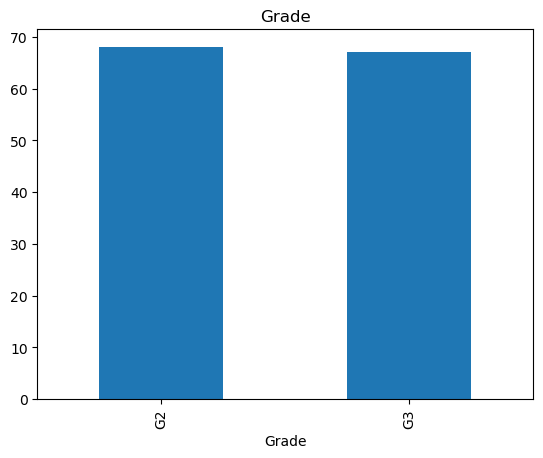

In [ ]:
# Lets know how many values
print("Grade        : \n",df1["Grade"].value_counts())
print("\n")
print(df1["Grade"].value_counts(normalize=True))

# plot.bar(title='') function is used to plot bargraph
df1["Grade"].value_counts().plot.bar(title="Grade")


In [ ]:
df1.corr(numeric_only=True)

,VoxelVolume,Maximum3DDiameter,MeshVolume,MajorAxisLength,Sphericity,LeastAxisLength,Elongation,SurfaceVolumeRatio,Maximum2DDiameterSlice,Flatness,...,HighGrayLevelZoneEmphasis.8,SmallAreaEmphasis.8,LowGrayLevelZoneEmphasis.8,ZoneEntropy.8,SmallAreaLowGrayLevelEmphasis.8,Coarseness.8,Complexity.8,Strength.8,Contrast.17,Busyness.8
VoxelVolume,1.000000,0.828242,0.999998,0.798965,-0.164740,0.941182,0.120243,-0.488728,0.821203,0.241213,...,0.347262,0.134924,-0.310077,0.488592,-0.302383,-0.593884,0.298711,-0.066294,-0.050545,0.023680
Maximum3DDiameter,0.828242,1.000000,0.828049,0.957472,-0.449739,0.787034,-0.189726,-0.246037,0.965595,-0.159845,...,0.355147,0.091080,-0.343286,0.506589,-0.337064,-0.719404,0.296146,-0.064366,-0.182724,0.063274
MeshVolume,0.999998,0.828049,1.000000,0.798748,-0.164555,0.941155,0.120333,-0.488841,0.821036,0.241439,...,0.347523,0.135250,-0.310165,0.489032,-0.302461,-0.593890,0.298877,-0.066292,-0.050051,0.023369
MajorAxisLength,0.798965,0.957472,0.798748,1.000000,-0.432744,0.752304,-0.298099,-0.249788,0.946469,-0.274776,...,0.344972,0.065519,-0.341957,0.500695,-0.338918,-0.729331,0.278475,-0.051804,-0.196954,0.074493
Sphericity,-0.164740,-0.449739,-0.164555,-0.432744,1.000000,-0.188589,0.256959,-0.635190,-0.469147,0.297429,...,-0.129162,0.129125,0.129382,-0.276516,0.129292,0.438290,-0.087262,0.096146,0.152417,-0.210373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Coarseness.8,-0.593884,-0.719404,-0.593890,-0.729331,0.438290,-0.675663,0.059113,0.171113,-0.713030,0.021547,...,-0.321542,0.050844,0.441662,-0.520893,0.451239,1.000000,-0.236360,0.147062,0.277662,-0.202305
Complexity.8,0.298711,0.296146,0.298877,0.278475,-0.087262,0.303689,0.028422,-0.142427,0.283121,0.050550,...,0.868760,0.614677,-0.243032,0.573545,-0.228010,-0.236360,1.000000,0.739986,0.119337,-0.318157
Strength.8,-0.066294,-0.064366,-0.066292,-0.051804,0.096146,-0.085839,0.064428,-0.026663,-0.074417,-0.060365,...,0.532246,0.605687,-0.195543,0.340745,-0.179257,0.147062,0.739986,1.000000,0.237551,-0.392751
Contrast.17,-0.050545,-0.182724,-0.050051,-0.196954,0.152417,-0.049874,0.257506,-0.069838,-0.188943,0.158120,...,0.107699,0.447622,-0.047110,0.220023,-0.039651,0.277662,0.119337,0.237551,1.000000,-0.295112


In [ ]:
df1.shape

(135, 852)

In [ ]:
X = df1.iloc[:,1:]
y = df1.iloc[:,0].replace({'G2':0,'G3':1}).values

In [ ]:
y

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1], dtype=int64)

# Dimensionality Reduction

In [ ]:
from sklearn.decomposition import PCA
pc=PCA(n_components=64)
data=pc.fit_transform(X,y)

In [ ]:
data.shape

(135, 64)

In [ ]:
data = pd.DataFrame(data)

In [ ]:
data.corr()>0.1

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
60,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
61,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
62,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


# Feature Selection

In [ ]:
from sklearn.feature_selection import SelectKBest,chi2,f_classif,f_oneway,f_regression

f=SelectKBest(score_func = f_classif, k=15)
my_data1=f.fit_transform(X,y)
my_data1.shape

(135, 15)

In [ ]:
f.get_feature_names_out()

array(['VoxelVolume', 'Maximum3DDiameter', 'MeshVolume', 'Sphericity',
       'MinorAxisLength', 'Maximum2DDiameterColumn', 'Skewness',
       'TotalEnergy', 'MCC.1', 'TotalEnergy.1', 'TotalEnergy.2',
       'RunEntropy.4', 'DependenceEntropy.7', 'Skewness.8',
       'TotalEnergy.8'], dtype=object)

In [ ]:
from sklearn.feature_selection import SelectPercentile

f=SelectPercentile(score_func = f_classif,percentile=30)
my_data2=f.fit_transform(X,y)
my_data2.shape

(135, 255)

In [ ]:
f.get_feature_names_out()

array(['VoxelVolume', 'Maximum3DDiameter', 'MeshVolume',
       'MajorAxisLength', 'Sphericity', 'LeastAxisLength',
       'SurfaceVolumeRatio', 'Maximum2DDiameterSlice', 'SurfaceArea',
       'MinorAxisLength', 'Maximum2DDiameterColumn',
       'Maximum2DDiameterRow', 'GrayLevelVariance',
       'SmallDependenceHighGrayLevelEmphasis',
       'SmallDependenceLowGrayLevelEmphasis', 'LowGrayLevelEmphasis',
       'ClusterShade', 'Idmn', 'Idn', 'SumSquares', 'Imc1',
       'ClusterTendency', 'InterquartileRange', 'Skewness', 'Median',
       'Energy', 'RobustMeanAbsoluteDeviation', 'MeanAbsoluteDeviation',
       'TotalEnergy', 'Maximum', 'RootMeanSquared', '90Percentile',
       'Minimum', 'Range', 'Variance', '10Percentile', 'Mean',
       'ShortRunLowGrayLevelEmphasis', 'GrayLevelVariance.1',
       'LowGrayLevelRunEmphasis', 'RunLengthNonUniformity', 'RunEntropy',
       'GrayLevelNonUniformityNormalized.1', 'SizeZoneNonUniformity',
       'LowGrayLevelZoneEmphasis', 'ZoneEntropy',
  

In [ ]:
from sklearn.feature_selection import GenericUnivariateSelect ,f_classif,chi2

selecting=GenericUnivariateSelect(score_func=f_classif,param=3,mode='k_best')
my_data3=selecting.fit_transform(data,df1.iloc[:,0])
my_data3.shape

(135, 3)

In [ ]:
selecting.get_feature_names_out()

array(['x24', 'x29', 'x49'], dtype=object)

In [ ]:
my_data1.shape

(135, 15)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier


# Create the RFE model and select 0.2 features
model = RandomForestClassifier()
rfe = RFE(estimator=model, n_features_to_select=6)  # None , float , int
fit = rfe.fit(my_data1,y)

# Get the ranking of features
print()


['x0' 'x3' 'x6' 'x11' 'x13' 'x14']


In [ ]:
# Get the ranking of features
fit.ranking_

array([ 1,  8,  2,  1,  4,  5,  1,  6,  3, 10,  9,  1,  7,  1,  1])

In [ ]:
# Get the ranking of features
fit.support_

array([ True, False, False,  True, False, False,  True, False, False,
       False, False,  True, False,  True,  True])

In [ ]:
type(my_data1)

numpy.ndarray

In [ ]:
pd.DataFrame(my_data1[:,fit.support_])

,0,1,2,3,4,5
0,66128.198147,0.429089,0.265525,3.792138,0.259407,4.774141e+10
1,42859.730845,0.242761,0.537026,3.710966,0.537487,4.109245e+11
2,82152.352810,0.631804,-0.401633,3.377708,-0.407478,3.104151e+11
3,170801.825047,0.522666,-0.285289,3.347147,-0.297257,6.488148e+11
4,183574.563980,0.406995,-0.789817,3.379464,-0.811805,5.072796e+11
...,...,...,...,...,...,...
130,11317.291260,0.493450,0.360811,3.593575,0.361758,3.169976e+09
131,18040.924072,0.585335,0.329189,3.727843,0.303263,5.135430e+09
132,36691.589355,0.522969,0.366005,3.797938,0.363736,1.099497e+10
133,17689.910889,0.693227,-1.171552,3.765455,-1.100766,5.113761e+09


In [ ]:
X=pd.read_csv('LIHC_data.csv')
y=pd.read_csv('LIHC_labels.csv')

<Axes: xlabel='0'>

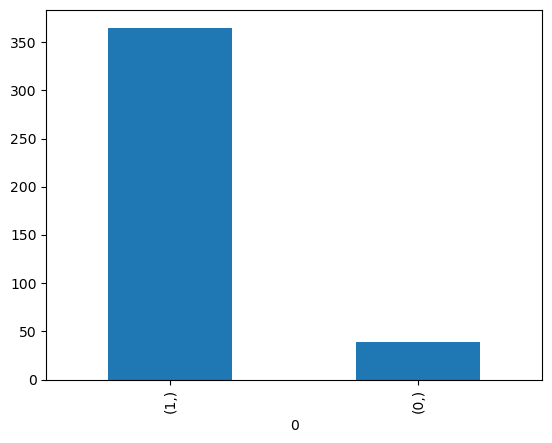

In [ ]:
y.value_counts().plot.bar()

# Balanced Data

## Over Sampling

In [ ]:
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=42)

In [ ]:
X,y=sm.fit_resample(X,y)

In [ ]:
X=pd.DataFrame(X)
y=pd.DataFrame(y)

<Axes: xlabel='0'>

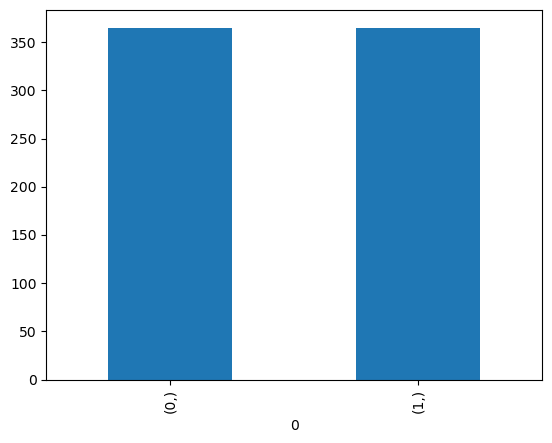

In [ ]:
y.value_counts().plot.bar()

In [ ]:
X.shape,y.shape

((730, 50), (730, 1))

## Under Sampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
sm=RandomUnderSampler(random_state=42)

In [ ]:
X,y=sm.fit_resample(X,y)

In [ ]:
X=pd.DataFrame(X)
y=pd.DataFrame(y)

<Axes: xlabel='0'>

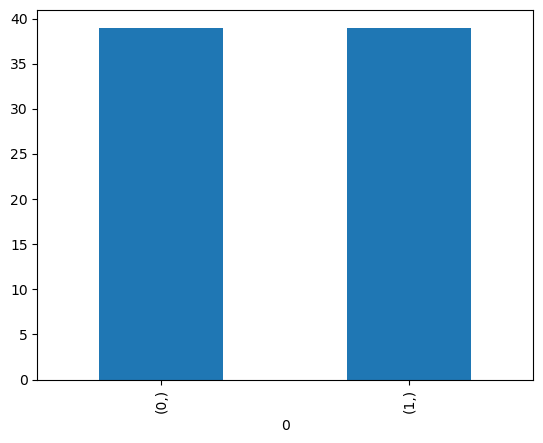

In [ ]:
y.value_counts().plot.bar()